In [9]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix
)
from sklearn.utils import shuffle
from collections import Counter
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [10]:
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.25, gamma=2.0, name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.alpha = alpha
        self.gamma = gamma
    
    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        
        ce = -y_true_one_hot * tf.math.log(y_pred)
        p_t = tf.where(tf.equal(y_true_one_hot, 1), y_pred, 1 - y_pred)
        focal_weight = tf.pow(1 - p_t, self.gamma)
        alpha_t = tf.where(tf.equal(y_true_one_hot, 1), self.alpha, 1 - self.alpha)
        focal_loss = alpha_t * focal_weight * ce
        
        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))
    
    def get_config(self):
        config = super().get_config()
        config.update({'alpha': self.alpha, 'gamma': self.gamma})
        return config
    
    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [11]:
with open('../models/training_config.pkl', 'rb') as f:
    config = pickle.load(f)

NUM_CLASSES = config['NUM_CLASSES']
LATENT_DIM = config['LATENT_DIM']

print(f"Configuration loaded")
print(f"  Classes: {NUM_CLASSES}")
print(f"  Latent dim: {LATENT_DIM}")

Configuration loaded
  Classes: 2
  Latent dim: 10


In [12]:
# Load SMOTE-balanced training data
with open('../data/client_data_processed.pkl', 'rb') as f:
    client_data = pickle.load(f)

X_train = np.vstack([x for x, _ in client_data])
y_train = np.concatenate([y for _, y in client_data])

print(f"Training data (SMOTE-balanced):")
print(f"  Samples: {len(y_train)}")
print(f"  Features: {X_train.shape[1]}")
print(f"  Distribution: {dict(Counter(y_train))}")

Training data (SMOTE-balanced):
  Samples: 4960
  Features: 15
  Distribution: {0: 3100, 1: 1860}


In [13]:
# Load the SAME test set that your federated model was evaluated on
with open('../data/test_set.pkl', 'rb') as f:
    X_test_processed, y_test = pickle.load(f)

print(f"\nTest data:")
print(f"  Samples: {len(y_test)}")
print(f"  Features: {X_test_processed.shape[1]}")
print(f"  Distribution: {dict(Counter(y_test))}")



Test data:
  Samples: 800
  Features: 15
  Distribution: {0: 775, 1: 25}


In [14]:
def build_simple_classifier(input_dim, num_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [15]:
print("\n" + "="*70)
print("BASELINE 1: CENTRALIZED MODEL")
print("="*70)

centralized_model = build_simple_classifier(X_train.shape[1], NUM_CLASSES)

print("\nTraining centralized model...")
history = centralized_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Evaluate
y_pred_centralized = np.argmax(centralized_model.predict(X_test_processed, verbose=0), axis=1)
acc_centralized = accuracy_score(y_test, y_pred_centralized)
rec_centralized = recall_score(y_test, y_pred_centralized, pos_label=1, zero_division=0)
prec_centralized = precision_score(y_test, y_pred_centralized, pos_label=1, zero_division=0)
f1_centralized = f1_score(y_test, y_pred_centralized, average='weighted')

print(f"\nCentralized Results:")
print(f"  Accuracy:  {acc_centralized:.4f}")
print(f"  Recall:    {rec_centralized:.4f}")
print(f"  Precision: {prec_centralized:.4f}")
print(f"  F1-Score:  {f1_centralized:.4f}")


BASELINE 1: CENTRALIZED MODEL

Training centralized model...

Centralized Results:
  Accuracy:  0.9912
  Recall:    0.9600
  Precision: 0.8000
  F1-Score:  0.9916


In [16]:
print("\n" + "="*70)
print("BASELINE 2: STANDARD FEDAVG")
print("="*70)

def fedavg_standard(client_data, X_test, y_test, num_rounds=30, local_epochs=2):
    input_dim = client_data[0][0].shape[1]
    global_model = build_simple_classifier(input_dim, NUM_CLASSES)
    
    print(f"\nTraining for {num_rounds} rounds...")
    
    for round_num in range(1, num_rounds + 1):
        local_weights = []
        local_sample_counts = []
        
        for cid, (X_client, y_client) in enumerate(client_data):
            if len(y_client) == 0:
                continue
            
            local_model = build_simple_classifier(input_dim, NUM_CLASSES)
            local_model.set_weights(global_model.get_weights())
            
            local_model.fit(
                X_client, y_client,
                epochs=local_epochs,
                batch_size=min(32, len(X_client)),
                verbose=0
            )
            
            local_weights.append(local_model.get_weights())
            local_sample_counts.append(len(y_client))
        
        # FedAvg aggregation
        total_samples = sum(local_sample_counts)
        averaged_weights = []
        
        for layer_idx in range(len(local_weights[0])):
            layer_sum = None
            for weights, count in zip(local_weights, local_sample_counts):
                scaled = weights[layer_idx] * (count / total_samples)
                layer_sum = scaled if layer_sum is None else layer_sum + scaled
            averaged_weights.append(layer_sum)
        
        global_model.set_weights(averaged_weights)
        
        if round_num % 10 == 0:
            _, test_acc = global_model.evaluate(X_test, y_test, verbose=0)
            print(f"  Round {round_num:2d}: Accuracy = {test_acc:.4f}")
    
    return global_model

fedavg_model = fedavg_standard(client_data, X_test_processed, y_test, num_rounds=30, local_epochs=2)

# Evaluate
y_pred_fedavg = np.argmax(fedavg_model.predict(X_test_processed, verbose=0), axis=1)
acc_fedavg = accuracy_score(y_test, y_pred_fedavg)
rec_fedavg = recall_score(y_test, y_pred_fedavg, pos_label=1, zero_division=0)
prec_fedavg = precision_score(y_test, y_pred_fedavg, pos_label=1, zero_division=0)
f1_fedavg = f1_score(y_test, y_pred_fedavg, average='weighted')

print(f"\nStandard FedAvg Results:")
print(f"  Accuracy:  {acc_fedavg:.4f}")
print(f"  Recall:    {rec_fedavg:.4f}")
print(f"  Precision: {prec_fedavg:.4f}")
print(f"  F1-Score:  {f1_fedavg:.4f}")


BASELINE 2: STANDARD FEDAVG

Training for 30 rounds...
  Round 10: Accuracy = 0.9775
  Round 20: Accuracy = 0.9875
  Round 30: Accuracy = 0.9950

Standard FedAvg Results:
  Accuracy:  0.9950
  Recall:    1.0000
  Precision: 0.8621
  F1-Score:  0.9952


In [17]:
print("\n" + "="*70)
print("YOUR METHOD: FEDERATED + AUTOENCODERS")
print("="*70)

# Load your trained model
BEST_ROUND = 3
model_path = f'../models/global_classifier_round{BEST_ROUND}.keras'

print(f"Loading model: {model_path}")
your_model = tf.keras.models.load_model(model_path, custom_objects={'FocalLoss': FocalLoss})
print(f"  Model input shape: {your_model.input_shape}")

# Load encoders
with open('../data/client_encoders.pkl', 'rb') as f:
    client_encoders = pickle.load(f)

# Get first valid encoder
encoder = None
for i, enc in enumerate(client_encoders):
    if enc is not None:
        encoder = enc
        print(f"  Using encoder from client {i}")
        print(f"  Encoder: {enc.input_shape} → {enc.output_shape}")
        break

if encoder is None:
    raise ValueError("No valid encoder found!")


YOUR METHOD: FEDERATED + AUTOENCODERS
Loading model: ../models/global_classifier_round3.keras


c:\Users\tejas\miniconda3\envs\ckd_fl\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Model input shape: (None, 10)
  Using encoder from client 0
  Encoder: (None, 15) → (None, 10)


In [18]:
# Transform test data to latent space using encoder
print("\nTransforming test data through autoencoder...")
X_test_latent = encoder.predict(X_test_processed, verbose=0)
print(f"  Transformed: {X_test_processed.shape} → {X_test_latent.shape}")

# Get predictions
y_pred_prob_yours = your_model.predict(X_test_latent, verbose=0)

# Use optimal threshold from Notebook 5
optimal_threshold = 0.35
y_pred_yours = (y_pred_prob_yours[:, 1] >= optimal_threshold).astype(int)

print(f"\nPredictions (threshold={optimal_threshold}):")
print(f"  Predicted: {dict(Counter(y_pred_yours))}")
print(f"  Actual:    {dict(Counter(y_test))}")

# Calculate metrics
acc_yours = accuracy_score(y_test, y_pred_yours)
rec_yours = recall_score(y_test, y_pred_yours, pos_label=1, zero_division=0)
prec_yours = precision_score(y_test, y_pred_yours, pos_label=1, zero_division=0)
f1_yours = f1_score(y_test, y_pred_yours, average='weighted')

# Confusion matrix
cm_yours = confusion_matrix(y_test, y_pred_yours)
tn, fp, fn, tp = cm_yours.ravel()

print(f"\nYour Method Results:")
print(f"  Accuracy:  {acc_yours:.4f}")
print(f"  Recall:    {rec_yours:.4f}")
print(f"  Precision: {prec_yours:.4f}")
print(f"  F1-Score:  {f1_yours:.4f}")
print(f"  Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")


Transforming test data through autoencoder...
  Transformed: (800, 15) → (800, 10)

Predictions (threshold=0.35):
  Predicted: {0: 624, 1: 176}
  Actual:    {0: 775, 1: 25}

Your Method Results:
  Accuracy:  0.8113
  Recall:    1.0000
  Precision: 0.1420
  F1-Score:  0.8720
  Confusion: TN=624, FP=151, FN=0, TP=25


In [19]:
print("\n" + "="*70)
print("FINAL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Method': ['Centralized', 'Standard FedAvg', 'Your Method'],
    'Accuracy': [acc_centralized, acc_fedavg, acc_yours],
    'Recall': [rec_centralized, rec_fedavg, rec_yours],
    'Precision': [prec_centralized, prec_fedavg, prec_yours],
    'F1-Score': [f1_centralized, f1_fedavg, f1_yours],
    'Privacy': ['None', 'Federated', 'Federated + DP'],
    'Features': ['Full (15D)', 'Full (15D)', 'Latent (10D)']
})

print("\n" + comparison_df.to_string(index=False))

# Save
os.makedirs('../results', exist_ok=True)
comparison_df.to_csv('../results/baseline_comparison.csv', index=False)
print("\nSaved: ../results/baseline_comparison.csv")


FINAL COMPARISON

         Method  Accuracy  Recall  Precision  F1-Score        Privacy     Features
    Centralized   0.99125    0.96   0.800000  0.991634           None   Full (15D)
Standard FedAvg   0.99500    1.00   0.862069  0.995179      Federated   Full (15D)
    Your Method   0.81125    1.00   0.142045  0.871962 Federated + DP Latent (10D)

Saved: ../results/baseline_comparison.csv


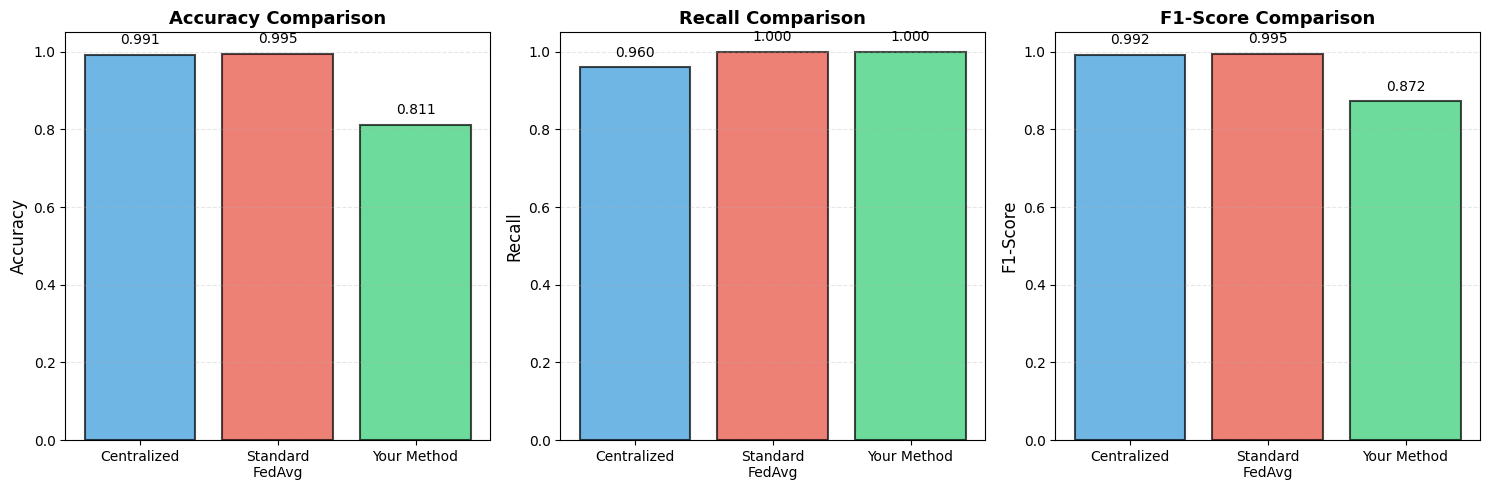

Saved: ../results/baseline_comparison.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = ['Centralized', 'Standard\nFedAvg', 'Your Method']
colors = ['#3498db', '#e74c3c', '#2ecc71']

metrics_data = [
    ('Accuracy', [acc_centralized, acc_fedavg, acc_yours]),
    ('Recall', [rec_centralized, rec_fedavg, rec_yours]),
    ('F1-Score', [f1_centralized, f1_fedavg, f1_yours])
]

for ax, (metric_name, values) in zip(axes, metrics_data):
    bars = ax.bar(methods, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric_name, fontsize=12)
    ax.set_title(f'{metric_name} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../results/baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: ../results/baseline_comparison.png")